# Volatility Drag vs Premium Drag in Deductible Optimization

Every insurance buyer faces a fundamental trade-off when choosing a deductible. A low deductible transfers most loss variance to the insurer, stabilising the company's equity path, but the premium consumes capital that would otherwise compound. A high deductible keeps premium low but exposes the balance sheet to volatile, potentially ruinous losses. Under **multiplicative dynamics** (where growth compounds year over year), this trade-off has a precise mathematical structure.

This notebook isolates the two forces, **premium drag** and **volatility drag**, and measures them on a common scale so that we can find the deductible that maximises the long-run, time-average equity growth rate for a representative manufacturing company.

In [13]:
"""Google Colab setup: mount Drive and install package dependencies.

Run this cell first. If prompted to restart the runtime, do so, then re-run all cells.
This cell is a no-op when running locally.
"""
import sys, os
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')

    NOTEBOOK_DIR = '/content/drive/My Drive/Colab Notebooks/ei_notebooks/optimization'

    os.chdir(NOTEBOOK_DIR)
    if NOTEBOOK_DIR not in sys.path:
        sys.path.append(NOTEBOOK_DIR)

    !pip install ergodic-insurance -q 2>&1 | tail -3
    print('\nSetup complete. If you see numpy/scipy import errors below,')
    print('restart the runtime (Runtime > Restart runtime) and re-run all cells.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Setup complete. If you see numpy/scipy import errors below,
restart the runtime (Runtime > Restart runtime) and re-run all cells.


## Setup

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.stats import norm as sp_norm, lognorm as sp_lognorm
from scipy.interpolate import interp1d
from multiprocessing import Pool, cpu_count
import warnings, logging, time, os

warnings.filterwarnings("ignore")
logging.getLogger("ergodic_insurance").setLevel(logging.ERROR)

from ergodic_insurance.visualization.core import (
    set_wsj_style, WSJ_COLORS, COLOR_SEQUENCE, WSJFormatter,
)
from ergodic_insurance.config import ManufacturerConfig
from ergodic_insurance.manufacturer import WidgetManufacturer
from ergodic_insurance.insurance_program import (
    EnhancedInsuranceLayer, InsuranceProgram,
)
from ergodic_insurance.loss_distributions import (
    ManufacturingLossGenerator, LognormalLoss, ParetoLoss,
)
from ergodic_insurance.insurance_pricing import LayerPricer

SEED = 20260223
np.random.seed(SEED)

N_CORES = cpu_count()
print(f"Using {N_CORES} cores for parallel computation")

Using 44 cores for parallel computation


## Part I — Company Configuration

We model a mid-market manufacturer with \$10M in total assets, 1.75x asset turnover, and a 15% operating margin before insurable losses. Revenue follows a log-normal process with 50% annual volatility. After-tax earnings are split 70/30 between retained earnings (equity growth) and dividends. These parameters produce roughly \$2.6M of annual operating income — enough to absorb routine losses, but vulnerable to a single large or catastrophic event.

In [15]:
# --- Economic Parameters ---
ATR = 1.75                 # Asset turnover ratio
OPERATING_MARGIN = 0.15   # 15% EBIT margin before insurable losses
REV_VOL = 0.50            # Revenue volatility
INITIAL_ASSETS = 10_000_000
TAX_RATE = 0.25
RETENTION_RATIO = 0.70    # 70% of earnings retained for growth

mfg_config = ManufacturerConfig(
    initial_assets=INITIAL_ASSETS,
    asset_turnover_ratio=ATR,
    base_operating_margin=OPERATING_MARGIN,
    tax_rate=TAX_RATE,
    retention_ratio=RETENTION_RATIO,
)

revenue = INITIAL_ASSETS * ATR
ebit = revenue * OPERATING_MARGIN
print("=" * 60)
print("MANUFACTURING COMPANY PROFILE")
print("=" * 60)
print(f"Total Assets:          ${INITIAL_ASSETS:>14,.0f}")
print(f"Annual Revenue:        ${revenue:>14,.0f}")
print(f"Operating Income:      ${ebit:>14,.0f}")
print(f"Operating Margin:      {OPERATING_MARGIN:>14.1%}")
print(f"Asset Turnover:        {ATR:>14.1f}x")
print(f"Revenue Volatility:    {REV_VOL:>14.2f}")
print(f"Tax Rate:              {TAX_RATE:>13.1%}")
print(f"Retention Ratio:       {RETENTION_RATIO:>13.1%}")
print("=" * 60)

MANUFACTURING COMPANY PROFILE
Total Assets:          $    10,000,000
Annual Revenue:        $    17,500,000
Operating Income:      $     2,625,000
Operating Margin:               15.0%
Asset Turnover:                   1.8x
Revenue Volatility:              0.50
Tax Rate:                      25.0%
Retention Ratio:               70.0%


## Part II — Loss Model & Insurance Pricing

The company faces a three-component compound-Poisson loss process:

| Component | Frequency | Severity | Distribution |
|---|---|---|---|
| **Attritional** | 5.0 / yr | \$10K mean (CV=3) | Lognormal |
| **Large** | 1.75 / yr | \$375K mean (CV=1.5) | Lognormal |
| **Catastrophic** | 0.15 / yr | \$1.5M min (α=2.01) | Pareto |

Claim frequency scales sub-linearly with revenue (exponent 0.75), so a company that doubles in size does not double its claim count.

Insurance is priced analytically using **Limited Expected Values** (LEVs). For a tower from retention $d$ to limit $L$, the pure premium is $E[\text{loss in }(d, L)] = \text{LEV}(L) - \text{LEV}(d)$, loaded by the insurer's claims-handling cost (9% LAE) and divided by the target loss ratio (0.70 for a Normal market). This approach produces rate-on-line that decreases naturally as the retention rises, matching real excess-layer pricing behaviour.

In [16]:
REFERENCE_REVENUE = ATR * INITIAL_ASSETS
FREQ_SCALING_EXPONENT = 0.75

# --- Loss Model Parameters ---
ATTR_BASE_FREQ = 5;       ATTR_SEV_MEAN = 10_000;      ATTR_SEV_CV = 3
LG_BASE_FREQ   = 1.75;      LG_SEV_MEAN   = 375_000;     LG_SEV_CV   = 1.5
CAT_BASE_FREQ  = 0.15;     CAT_SEV_ALPHA = 2.01;         CAT_SEV_XM  = 1_500_000

LOSS_PARAMS = dict(
    attritional_params=dict(base_frequency=ATTR_BASE_FREQ,
                            severity_mean=ATTR_SEV_MEAN, severity_cv=ATTR_SEV_CV,
                            revenue_scaling_exponent=FREQ_SCALING_EXPONENT,
                            reference_revenue=REFERENCE_REVENUE),
    large_params=dict(base_frequency=LG_BASE_FREQ,
                      severity_mean=LG_SEV_MEAN, severity_cv=LG_SEV_CV,
                      revenue_scaling_exponent=FREQ_SCALING_EXPONENT,
                      reference_revenue=REFERENCE_REVENUE),
    catastrophic_params=dict(base_frequency=CAT_BASE_FREQ,
                             severity_alpha=CAT_SEV_ALPHA, severity_xm=CAT_SEV_XM,
                             revenue_scaling_exponent=FREQ_SCALING_EXPONENT,
                             reference_revenue=REFERENCE_REVENUE),
)

# Lognormal distribution parameters
attr_var = np.log(1 + ATTR_SEV_CV**2)
attr_mu  = np.log(ATTR_SEV_MEAN) - attr_var / 2
attr_sig = np.sqrt(attr_var)

lg_var = np.log(1 + LG_SEV_CV**2)
lg_mu  = np.log(LG_SEV_MEAN) - lg_var / 2
lg_sig = np.sqrt(lg_var)

# --- Vectorized LEV functions (Klugman, Panjer & Willmot, Ch. 5) ---
def lev_lognormal(d, mu, sigma):
    d = np.asarray(d, dtype=float)
    safe_d = np.maximum(d, 1e-10)
    mean = np.exp(mu + sigma**2 / 2)
    z1 = (np.log(safe_d) - mu - sigma**2) / sigma
    z2 = (np.log(safe_d) - mu) / sigma
    return mean * sp_norm.cdf(z1) + d * (1 - sp_norm.cdf(z2))

def lev_pareto(d, alpha, xm):
    d = np.asarray(d, dtype=float)
    safe_d = np.maximum(d, xm)
    return np.where(
        d <= xm, d,
        alpha * xm / (alpha - 1) * (1 - (xm / safe_d)**(alpha - 1))
        + d * (xm / safe_d)**alpha
    )

def expected_retained(retention, revenue):
    """E[losses below retention] per year, vectorized."""
    s = (revenue / REFERENCE_REVENUE) ** FREQ_SCALING_EXPONENT
    return (ATTR_BASE_FREQ * s * lev_lognormal(retention, attr_mu, attr_sig)
          + LG_BASE_FREQ   * s * lev_lognormal(retention, lg_mu, lg_sig)
          + CAT_BASE_FREQ  * s * lev_pareto(retention, CAT_SEV_ALPHA, CAT_SEV_XM))

def expected_insured(retention, max_limit, revenue):
    """E[losses in the tower (retention, max_limit)] per year, vectorized."""
    s = (revenue / REFERENCE_REVENUE) ** FREQ_SCALING_EXPONENT
    lev_lim = (ATTR_BASE_FREQ * s * lev_lognormal(max_limit, attr_mu, attr_sig)
             + LG_BASE_FREQ   * s * lev_lognormal(max_limit, lg_mu, lg_sig)
             + CAT_BASE_FREQ  * s * lev_pareto(max_limit, CAT_SEV_ALPHA, CAT_SEV_XM))
    return lev_lim - expected_retained(retention, revenue)

def compute_premium(retention, max_limit, loss_ratio, revenue):
    """Annual tower premium with LAE loading, vectorized.

    Premium = E[insured] * (1 + RETAINED_LAE_RATIO) / loss_ratio

    The insurer incurs claims-handling costs (RETAINED_LAE_RATIO) on insured
    losses and passes them through in the premium, mirroring the LAE loading
    in InsurancePricer.calculate_technical_premium().
    """
    ins = expected_insured(retention, max_limit, revenue)
    return np.where(max_limit > retention,
                    ins * (1 + RETAINED_LAE_RATIO) / loss_ratio, 0.0)

def expected_total_losses(revenue):
    s = (revenue / REFERENCE_REVENUE) ** FREQ_SCALING_EXPONENT
    a_mean = np.exp(attr_mu + attr_var / 2)
    l_mean = np.exp(lg_mu + lg_var / 2)
    c_mean = CAT_SEV_ALPHA * CAT_SEV_XM / (CAT_SEV_ALPHA - 1)
    return s * (ATTR_BASE_FREQ * a_mean + LG_BASE_FREQ * l_mean + CAT_BASE_FREQ * c_mean)

# Quick validation
_el = expected_total_losses(REFERENCE_REVENUE)
_oi = INITIAL_ASSETS * ATR * OPERATING_MARGIN
print(f"Loss model validation:")
print(f"  Expected annual loss:  ${_el:>12,.0f}")
print(f"  Operating income:      ${_oi:>12,.0f}")
print(f"  Loss / Income ratio:   {_el / _oi:.0%}")

Loss model validation:
  Expected annual loss:  $   1,154,022
  Operating income:      $   2,625,000
  Loss / Income ratio:   44%


## Part III — Deductible Sweep

### Experiment Design

We fix the insurance limit at **\$200M** in a **Normal market** (0.70 loss ratio) and sweep the deductible from \$10K to \$100M. Each deductible is held **static** across all 25 years, meaning the company buys the same dollar retention every year regardless of growth. All scenario paths share identical loss events and revenue shocks via **Common Random Numbers** (CRN); the only difference is the deductible. A self-insured baseline (no insurance at all) provides the reference point.

### What We Measure

**Sharpe Ratio** = $\mu / \sigma$, where $\mu$ is the mean annual log-equity-return and $\sigma$ is its standard deviation. This is the central metric: the risk-adjusted rate at which equity compounds over time. It synthesises both costs of the deductible choice and is what we optimise.

The Sharpe ratio depends on two quantities that move in opposite directions as the deductible rises:

**$\mu$ (mean log-return)** is the time-average equity growth rate. At low deductibles, $\mu$ is suppressed because the premium takes a large bite out of annual earnings. As the deductible rises, less premium is paid and $\mu$ increases, eventually plateauing once the premium becomes negligible relative to retained losses and other costs.

**$\sigma$ (volatility of log-returns)** is the standard deviation of annual equity returns. At low deductibles the insurer absorbs most loss variance, so $\sigma$ is small and driven mainly by revenue volatility. As the deductible rises the company retains more loss variance, and $\sigma$ expands. This matters doubly for the Sharpe ratio:

1. $\sigma$ appears in the **denominator** of $\mu/\sigma$, so higher volatility directly dilutes the risk-adjusted return.
2. Under multiplicative dynamics, variance also penalises the **numerator** via the Kelly drag $\sigma^2/2$ (the gap between the arithmetic and geometric mean returns). A 50% gain followed by a 50% loss does not return to par; it returns to 75%.

The Sharpe ratio peaks where the marginal premium saving from raising the deductible exactly balances the marginal $\sigma$ increase. Beyond that point, even though the company saves on premium, the rising $\sigma$ erodes both the numerator and denominator of Sharpe faster than $\mu$ can recover.

### Growth Rate Decomposition

To understand where the growth rate goes, we also track the additive decomposition:

$$g \;\approx\; \underbrace{(1-\tau)\rho \; E\!\left[\frac{\text{operating return}}{W}\right]}_{\text{gross growth}} \;-\; \underbrace{(1-\tau)\rho \; E\!\left[\frac{\text{premium}}{W}\right]}_{\text{premium drag}} \;-\; \underbrace{\frac{\sigma^2}{2}}_{\text{volatility drag}}$$

**Premium Drag** = $(1-\tau)\rho \times E[\text{premium}/W]$ is the effective reduction in equity growth from insurance cost, after tax ($\tau=25\%$) and retention ($\rho=70\%$) adjustments. Only the fraction 0.525 of each premium dollar actually comes out of retained equity. We report this effective number so that it is directly additive with volatility drag.

**Volatility Drag** = $\sigma^2/2$ is the Kelly penalty on the growth rate. Note: because this is *quadratic* in $\sigma$, it understates the visual impact on the Sharpe ratio, where $\sigma$ enters *linearly* in the denominator. A 4$\times$ change in $\sigma^2/2$ (e.g. 0.2% $\to$ 0.8%) corresponds to only a 2$\times$ change in $\sigma$ (7% $\to$ 13%), but that 2$\times$ denominator change halves the Sharpe ratio.

### Optimal Deductible

The optimal deductible maximises a blended objective that combines Sharpe (growth efficiency) with a ruin penalty (survival):

$$\mathcal{J}(d) = 0.85 \times \text{Sharpe}(d) \;+\; 0.15 \times N \ln P\!\left(\text{survive}_1(d)\right)$$

The ruin term uses the annual survival probability raised to the planning horizon $N$, so that a seemingly small 0.5%/year ruin rate registers as a 12% cumulative probability over 25 years — a risk no board would ignore.

In [17]:
# --- Simulation constants ---
N_YEARS = 25
N_SCENARIOS = 1_000_000
NORMAL_LR = 0.70       # Normal market loss ratio (every year)
LIMIT = 200e6          # Fixed $200M limit for all deductibles
SHARPE_WEIGHT = 0.85   # Weight on Sharpe in blended objective
RUIN_WEIGHT = 0.15     # Weight on ruin penalty

INTERNAL_LAE_RATIO = 0.03     # Internal claims admin on ALL gross losses
RETAINED_LAE_RATIO = 0.09     # Additional cost for self-adjusted retained claims
LETTER_OF_CREDIT_RATE = 0.015  # Annual collateral cost on retention

# Deductible grid (26 points from $10K to $100M)
DEDUCTIBLE_GRID = np.array([
    10_000, 25_000, 50_000, 100_000, 150_000,
    200_000, 250_000, 350_000, 500_000, 750_000,
    1e6, 1.5e6, 2e6, 2.5e6, 3e6, 4e6, 5e6,
    7.5e6, 10e6, 15e6, 20e6, 25e6, 35e6,
    50e6, 75e6, 100e6,
])
n_ded = len(DEDUCTIBLE_GRID)

print(f"Configuration: {N_SCENARIOS:,} scenarios × {N_YEARS} years")
print(f"  Normal market (LR={NORMAL_LR}), fixed limit=${LIMIT/1e6:.0f}M")
print(f"  Objective: {SHARPE_WEIGHT:.0%} Sharpe + {RUIN_WEIGHT:.0%} ruin penalty")
print(f"  LAE: {INTERNAL_LAE_RATIO:.0%} internal (all claims) "
      f"+ {RETAINED_LAE_RATIO:.0%} retained (self-adjusted)")
print(f"  Deductible grid: {n_ded} points "
      f"(${DEDUCTIBLE_GRID[0]/1e3:.0f}K – ${DEDUCTIBLE_GRID[-1]/1e6:.0f}M)")

# --- Generate CRN loss pool (shared across all deductibles) ---
print(f"\nGenerating CRN loss pool on {N_CORES} cores ...")
t0 = time.time()

def _gen_crn_scenario(args):
    """Generate one scenario path of losses at reference revenue."""
    i, seed_val = args
    gen = ManufacturingLossGenerator(**LOSS_PARAMS, seed=seed_val)
    path = []
    for t in range(N_YEARS):
        evts, _ = gen.generate_losses(duration=1.0, revenue=REFERENCE_REVENUE)
        path.append([e.amount for e in evts])
    return i, path

ss = np.random.SeedSequence(SEED + 200)
children = ss.spawn(N_SCENARIOS + 1)
crn_rev_shocks = np.random.default_rng(children[0]).standard_normal(
    (N_SCENARIOS, N_YEARS))
crn_tasks = [(i, int(children[i + 1].generate_state(1)[0] % (2**31)))
             for i in range(N_SCENARIOS)]

with Pool(N_CORES) as pool:
    crn_results = pool.map(_gen_crn_scenario, crn_tasks, chunksize=32)

_mx = max(len(a) for _, path in crn_results for a in path)
crn_loss_amounts = np.zeros((N_SCENARIOS, N_YEARS, _mx))
for i, path in crn_results:
    for t, a in enumerate(path):
        crn_loss_amounts[i, t, :len(a)] = a
del crn_results
print(f"  Done in {time.time()-t0:.1f}s  (max {_mx} events/yr)")

Configuration: 1,000,000 scenarios × 25 years
  Normal market (LR=0.7), fixed limit=$200M
  Objective: 85% Sharpe + 15% ruin penalty
  LAE: 3% internal (all claims) + 9% retained (self-adjusted)
  Deductible grid: 26 points ($10K – $100M)

Generating CRN loss pool on 44 cores ...
  Done in 107.8s  (max 25 events/yr)


In [18]:
# --- Run deductible sweep ---
print(f"Sweeping {n_ded} deductibles ...")
t0 = time.time()

# Store wealth paths: (n_ded, N_SCENARIOS, N_YEARS+1)
all_paths = np.zeros((n_ded, N_SCENARIOS, N_YEARS + 1))
all_paths[:, :, 0] = INITIAL_ASSETS
all_premiums = np.zeros((n_ded, N_SCENARIOS, N_YEARS))
all_retained = np.zeros((n_ded, N_SCENARIOS, N_YEARS))

RUIN_CAPITAL_FLOOR = INITIAL_ASSETS * 0.10  # suspend dividends below 10% of starting capital

for di, ded in enumerate(DEDUCTIBLE_GRID):
    layer_cap = LIMIT - ded
    for t in range(N_YEARS):
        assets = all_paths[di, :, t].copy()
        alive = assets > 0

        # Revenue with shared CRN shock (log-normal, drift-corrected)
        rev = assets * ATR * np.exp(
            REV_VOL * crn_rev_shocks[:, t] - 0.5 * REV_VOL**2)
        rev = np.maximum(rev, 1.0)
        op_inc = rev * OPERATING_MARGIN

        # Scale CRN losses to realised revenue
        scale = (rev / REFERENCE_REVENUE) ** FREQ_SCALING_EXPONENT
        scaled = crn_loss_amounts[:, t, :] * scale[:, None]

        # Insurance allocation: retained = below deductible + above limit
        retained_per_ev = (np.minimum(scaled, ded)
                           + np.maximum(0.0, scaled - LIMIT))
        tot_retained = retained_per_ev.sum(axis=1)
        tot_gross = scaled.sum(axis=1)

        # Premium at expected revenue (locked at policy inception)
        rev_exp = np.maximum(assets * ATR, 1.0)
        prem = compute_premium(ded, LIMIT, NORMAL_LR, rev_exp)

        all_premiums[di, :, t] = prem
        all_retained[di, :, t] = tot_retained

        # Split LAE: internal on all claims + retained on self-adjusted
        lae = tot_gross * INTERNAL_LAE_RATIO + tot_retained * RETAINED_LAE_RATIO

        # Collateral sized to expected retained losses (LOC secures
        # the company's ability to pay claims below the deductible)
        collateral_cost = expected_retained(ded, rev_exp) * LETTER_OF_CREDIT_RATE

        gross = op_inc - tot_retained - prem - lae - collateral_cost

        # Tax shield on losses (IRC §172 NOL carryforward)
        after_tax = gross * (1 - TAX_RATE)

        # Suspend dividends when capital falls below floor
        capital_adequate = assets > RUIN_CAPITAL_FLOOR
        effective_retention = np.where(capital_adequate, RETENTION_RATIO, 1.0)

        delta = np.where(gross >= 0,
                         after_tax * effective_retention,
                         after_tax)
        all_paths[di, :, t + 1] = np.where(
            alive, np.maximum(assets + delta, 0.0), 0.0)

# --- Self-insured baseline (no insurance) ---
si_paths = np.zeros((N_SCENARIOS, N_YEARS + 1))
si_paths[:, 0] = INITIAL_ASSETS
for t in range(N_YEARS):
    assets = si_paths[:, t].copy()
    alive = assets > 0
    rev = assets * ATR * np.exp(
        REV_VOL * crn_rev_shocks[:, t] - 0.5 * REV_VOL**2)
    rev = np.maximum(rev, 1.0)
    op_inc = rev * OPERATING_MARGIN
    scale = (rev / REFERENCE_REVENUE) ** FREQ_SCALING_EXPONENT
    scaled = crn_loss_amounts[:, t, :] * scale[:, None]
    tot_losses = scaled.sum(axis=1)

    # Self-insured bears both internal + retained LAE on all claims
    lae = tot_losses * (INTERNAL_LAE_RATIO + RETAINED_LAE_RATIO)

    gross = op_inc - tot_losses - lae

    # Tax shield on losses (IRC §172 NOL carryforward)
    after_tax = gross * (1 - TAX_RATE)

    # Suspend dividends when capital falls below floor
    capital_adequate = assets > RUIN_CAPITAL_FLOOR
    effective_retention = np.where(capital_adequate, RETENTION_RATIO, 1.0)

    delta = np.where(gross >= 0,
                     after_tax * effective_retention,
                     after_tax)
    si_paths[:, t + 1] = np.where(
        alive, np.maximum(assets + delta, 0.0), 0.0)

print(f"  Done in {time.time()-t0:.1f}s")

Sweeping 26 deductibles ...
  Done in 174.8s


In [19]:
# --- Compute metrics for each deductible ---
premium_drags = np.zeros(n_ded)
raw_premium_pcts = np.zeros(n_ded)   # raw E[prem/W] for reference
vol_drags = np.zeros(n_ded)
sharpe_ratios = np.zeros(n_ded)
ruin_probs = np.zeros(n_ded)
ta_growth_rates = np.zeros(n_ded)
mean_log_rets = np.zeros(n_ded)
std_log_rets = np.zeros(n_ded)
blended_objectives = np.zeros(n_ded)

for di in range(n_ded):
    paths_d = all_paths[di]   # (N_SCENARIOS, N_YEARS+1)
    final_w = paths_d[:, -1]
    alive_mask = final_w > 0
    surv_rate = alive_mask.mean()
    ruin_probs[di] = 1 - surv_rate

    log_rets = np.diff(np.log(np.maximum(paths_d, 1)), axis=1)

    if surv_rate > 0:
        flat_lr = log_rets[alive_mask].ravel()
        mu = np.mean(flat_lr)
        sigma = np.std(flat_lr)
        mean_log_rets[di] = mu
        std_log_rets[di] = sigma

        ta_growth_rates[di] = np.mean(
            np.log(np.maximum(final_w[alive_mask], 1) / INITIAL_ASSETS)
            / N_YEARS)
        vol_drags[di] = sigma**2 / 2
        sharpe_ratios[di] = mu / sigma if sigma > 0 else 0

        # Premium drag: effective impact on equity growth rate
        # Premium reduces after-tax retained earnings by prem × (1-τ) × ρ,
        # so the growth-rate impact is E[prem × (1-τ) × ρ / W].
        # This puts premium drag in the same units as vol drag (σ²/2),
        # making them additive in the decomposition: g ≈ gross - prem_drag - vol_drag
        alive_assets = paths_d[alive_mask, :-1]
        alive_prems = all_premiums[di][alive_mask]
        raw_prem_ratio = np.mean(
            alive_prems / np.maximum(alive_assets, 1.0))
        raw_premium_pcts[di] = raw_prem_ratio
        premium_drags[di] = raw_prem_ratio * (1 - TAX_RATE) * RETENTION_RATIO

        # Ruin penalty via person-year death rate
        alive_start = (paths_d[:, :-1] > 0)
        died_during = alive_start & (paths_d[:, 1:] == 0)
        total_py = alive_start.sum()
        total_deaths = died_during.sum()
        ann_ruin = total_deaths / total_py if total_py > 0 else 1.0
        p_s1 = 1 - ann_ruin
        ruin_pen = (N_YEARS * np.log(p_s1)) if p_s1 > 0 else -100.0
        blended_objectives[di] = (
            SHARPE_WEIGHT * sharpe_ratios[di] + RUIN_WEIGHT * ruin_pen)
    else:
        for arr in (premium_drags, raw_premium_pcts, vol_drags,
                    mean_log_rets, std_log_rets, ta_growth_rates):
            arr[di] = np.nan
        blended_objectives[di] = -np.inf

# --- Self-insured baseline ---
si_final = si_paths[:, -1]
si_alive = si_final > 0
si_surv = si_alive.mean()
si_lr = np.diff(np.log(np.maximum(si_paths, 1)), axis=1)
si_flat = si_lr[si_alive].ravel() if si_surv > 0 else np.array([0.0])
si_ta = (np.mean(np.log(np.maximum(si_final[si_alive], 1)
                        / INITIAL_ASSETS) / N_YEARS)
         if si_surv > 0 else 0)
si_sigma = np.std(si_flat)
si_vol_drag = si_sigma**2 / 2
si_sharpe = np.mean(si_flat) / si_sigma if si_sigma > 0 else 0

# --- Optimal deductible ---
opt_idx = np.argmax(blended_objectives)
opt_ded = DEDUCTIBLE_GRID[opt_idx]

# Derived quantities for plotting
ded_M = DEDUCTIBLE_GRID / 1e6
opt_M = opt_ded / 1e6

# --- Results table ---
_eff = (1 - TAX_RATE) * RETENTION_RATIO
print("=" * 120)
print(f"  DEDUCTIBLE SWEEP  (Normal market, LR={NORMAL_LR}, "
      f"limit=${LIMIT/1e6:.0f}M, "
      f"{N_SCENARIOS:,} paths x {N_YEARS} yr)")
print("=" * 120)
print(f"  {'Deductible':>12s}  {'Prem/Eq':>8s}  {'Prem Drag':>10s}  "
      f"{'Vol Drag':>10s}  {'Sharpe':>8s}  {'TA Growth':>10s}  "
      f"{'Ruin %':>8s}  {'Objective':>10s}")
print("-" * 120)
for di in range(n_ded):
    tag = "  << OPTIMAL" if di == opt_idx else ""
    print(f"  ${DEDUCTIBLE_GRID[di]/1e6:>9.3f}M  "
          f"{raw_premium_pcts[di]:>7.1%}  "
          f"{premium_drags[di]:>10.4f}  {vol_drags[di]:>10.4f}  "
          f"{sharpe_ratios[di]:>8.3f}  {ta_growth_rates[di]:>9.2%}  "
          f"{ruin_probs[di]:>7.1%}  "
          f"{blended_objectives[di]:>+10.4f}{tag}")
print("-" * 120)
print(f"  Self-Insured:              0.0000  {si_vol_drag:>10.4f}  "
      f"{si_sharpe:>8.3f}  {si_ta:>9.2%}  "
      f"{1 - si_surv:>7.1%}")
print(f"\n  >> Optimal deductible: ${opt_ded:,.0f}  "
      f"(Sharpe={sharpe_ratios[opt_idx]:.3f}, "
      f"Ruin={ruin_probs[opt_idx]:.1%}, "
      f"Obj={blended_objectives[opt_idx]:+.4f})")
print(f"  >> Effective drag factor: (1-τ)×ρ = {_eff:.3f} "
      f"(Prem Drag = {_eff:.3f} × Prem/Eq)")
print("=" * 120)

  DEDUCTIBLE SWEEP  (Normal market, LR=0.7, limit=$200M, 1,000,000 paths x 25 yr)
    Deductible   Prem/Eq   Prem Drag    Vol Drag    Sharpe   TA Growth    Ruin %   Objective
------------------------------------------------------------------------------------------------------------------------
  $    0.010M    15.2%      0.0800      0.0024     0.710      4.90%     0.0%     +0.6034
  $    0.025M    14.6%      0.0769      0.0024     0.738      5.06%     0.0%     +0.6274
  $    0.050M    13.9%      0.0728      0.0023     0.776      5.29%     0.0%     +0.6596
  $    0.100M    12.6%      0.0661      0.0023     0.838      5.66%     0.1%     +0.7120
  $    0.150M    11.6%      0.0608      0.0023     0.887      5.96%     0.1%     +0.7542
  $    0.200M    10.7%      0.0564      0.0022     0.927      6.20%     0.1%     +0.7880
  $    0.250M    10.0%      0.0527      0.0022     0.960      6.39%     0.1%     +0.8156
  $    0.350M     8.9%      0.0467      0.0022     1.009      6.69%     0.1%     

## Part IV — Analysis

### Reading the Results

The table above shows how the metrics evolve across the deductible grid. Several patterns stand out:

- **$\mu$ rises, then flattens.** As the deductible increases, the company pays less premium and $\mu$ rises. But only up to a point. Once the premium is negligible, $\mu$ is limited by operating income minus retained losses. Further deductible increases barely move $\mu$ because the losses retained above $\sim\$5M$ are rare events with small expected value.
- **$\sigma$ stays flat, then expands.** At low deductibles, $\sigma$ is driven almost entirely by revenue volatility, since loss variance is absorbed by the insurer. Above $\sim\$1M$ the company begins retaining large losses and $\sigma$ grows substantially.
- **Sharpe peaks where the $\mu/\sigma$ trade-off is best.** The Sharpe ratio rises as $\mu$ climbs (premium falls) and collapses once $\sigma$ takes over. The peak is the optimal risk-efficiency point.
- **The optimal sits below the Sharpe peak.** The blended objective also penalises ruin risk, pulling the optimum toward lower deductibles where survival is nearly certain.

### Why $\sigma^2/2$ Understates the Sharpe Impact

The growth-rate decomposition chart shows volatility drag as $\sigma^2/2$, which is the correct additive term in:

$$g \approx \mu_{\text{arith}} - \sigma^2/2$$

But the Sharpe ratio is $\mu/\sigma$, not $g$. Volatility hits the Sharpe ratio through **two channels**: $\sigma^2/2$ reduces the numerator $\mu$, and $\sigma$ inflates the denominator. Because $\sigma^2/2$ is *quadratic* in $\sigma$, it compresses large changes in $\sigma$ into small-looking numbers. A doubling of $\sigma$ from 7% to 13% shows up as a modest increase in $\sigma^2/2$ (from 0.24% to 0.85%) — but it halves the Sharpe ratio. The Sharpe decomposition chart (Plot 1) shows $\mu$ and $\sigma$ directly so the reader can see both channels at work.

### Modelling Notes

**Scale consistency.** In the growth-rate decomposition (Plot 2), both premium drag and vol drag are measured as their effective impact on the log-equity growth rate (% per year). Premium drag is the raw premium-to-equity ratio multiplied by $(1-\tau)\rho = 0.525$, because only the after-tax retained portion of the premium actually reduces equity accumulation. Volatility drag is $\sigma^2/2$ of log-equity-returns, which already incorporates tax and retention effects. These two quantities are directly additive in the growth equation.

**LAE split.** Loss adjustment expenses are split into an *internal* ratio (3%) charged on all gross losses regardless of insurance, and a *retained* ratio (9%) charged only on claims the company self-adjusts below the deductible. The insurer builds its own claims-handling cost (9%) into the premium for the insured layer. At low deductibles almost all LAE is embedded in the premium; at high deductibles the company bears the full 12% directly.

**Collateral asymmetry.** Insured scenarios post a letter of credit sized to expected retained losses, securing the deductible obligation. The self-insured baseline carries no collateral cost because there is no third-party insurer to secure. This gives self-insurance a small structural cost advantage that partially offsets its higher volatility drag.

**Tax symmetry.** Both gains and losses are taxed at 25%, reflecting IRC §172 NOL carryforward. This avoids the unrealistic $\sim$1.9$\times$ downside leverage that would result from taxing only gains.

**Dividend suspension.** Dividends are suspended when equity falls below 10% of starting capital. All after-tax income is retained to rebuild the capital base, matching real-world board behaviour near insolvency.

## Part V — Diagnostic Plots

Five charts illustrate the trade-off:

1. **Sharpe decomposition** — the headline chart. Shows the two components of the Sharpe ratio ($\mu$ and $\sigma$) as a function of deductible. The reader can see directly why Sharpe peaks where it does: $\mu$ rises as premium falls, $\sigma$ expands as more loss variance is retained, and the ratio $\mu/\sigma$ peaks at the balance point.
2. **Growth rate decomposition** — breaks down the time-average growth rate $g$ into its additive components: effective premium drag and volatility drag ($\sigma^2/2$). Shows where total drag is minimised.
3. **Ruin and blended objective** — how ruin probability escalates at high deductibles and how the blended objective selects the optimum.
4. **Wealth distributions** — box plots and fan charts comparing low, optimal, high, and self-insured strategies over 25 years.

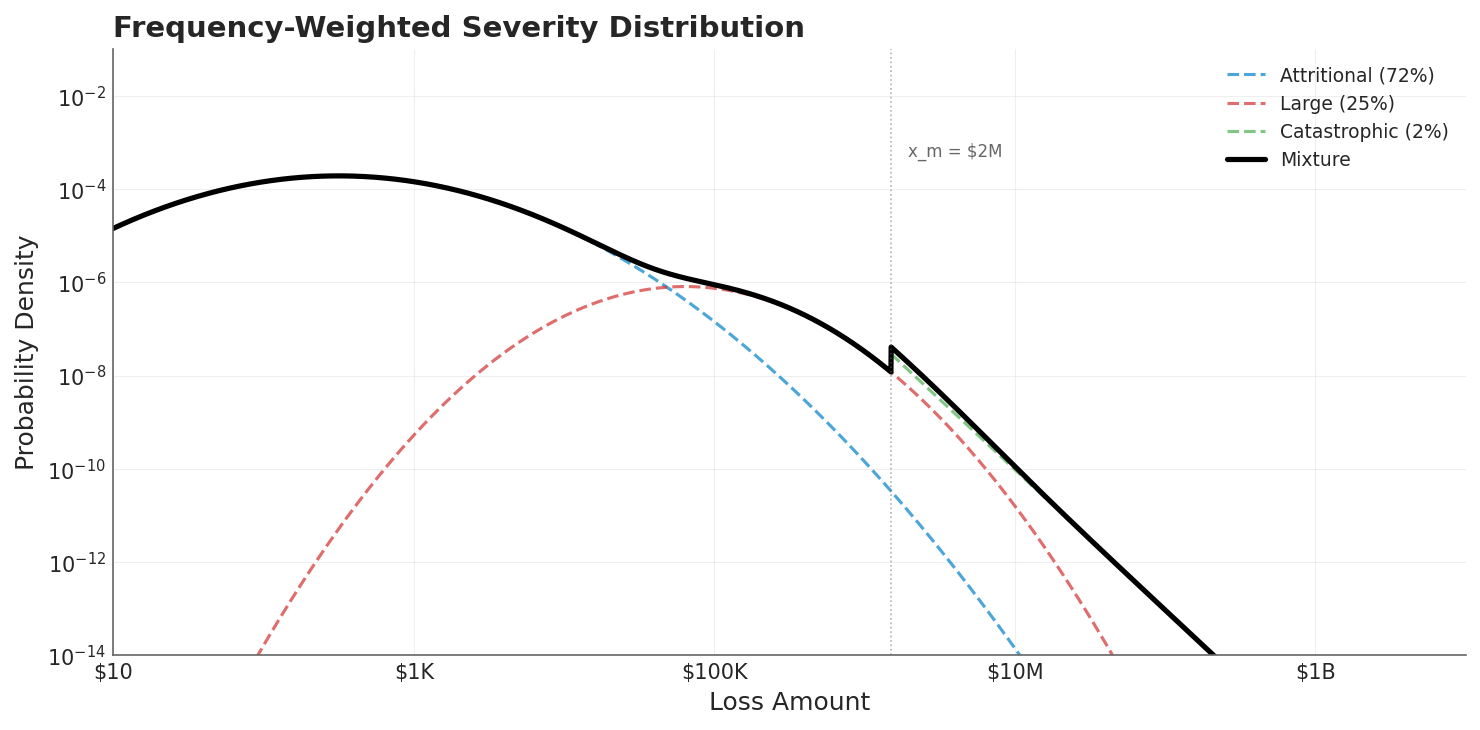

In [20]:
def dollar_fmt(x, pos):
    if x >= 1e9:  return f'${x/1e9:.0f}B'
    elif x >= 1e6: return f'${x/1e6:.0f}M'
    elif x >= 1e3: return f'${x/1e3:.0f}K'
    return f'${x:.0f}'

set_wsj_style()
os.makedirs('cache', exist_ok=True)

xg = np.logspace(0, 10, 8000)
freq_total = ATTR_BASE_FREQ + LG_BASE_FREQ + CAT_BASE_FREQ
w_a = ATTR_BASE_FREQ / freq_total
w_l = LG_BASE_FREQ   / freq_total
w_c = CAT_BASE_FREQ  / freq_total

pdf_a = sp_lognorm.pdf(xg, s=attr_sig, scale=np.exp(attr_mu))
pdf_l = sp_lognorm.pdf(xg, s=lg_sig,   scale=np.exp(lg_mu))
cat_mask = xg >= CAT_SEV_XM
pdf_c = np.where(cat_mask,
                 CAT_SEV_ALPHA * CAT_SEV_XM**CAT_SEV_ALPHA
                 * xg**(-CAT_SEV_ALPHA - 1), 0.0)
pdf_mix = w_a * pdf_a + w_l * pdf_l + w_c * pdf_c

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
ax.loglog(xg, w_a * pdf_a, color=COLOR_SEQUENCE[0], lw=1.5, ls='--',
          alpha=0.7, label=f"Attritional ({w_a:.0%})")
ax.loglog(xg, w_l * pdf_l, color=COLOR_SEQUENCE[1], lw=1.5, ls='--',
          alpha=0.7, label=f"Large ({w_l:.0%})")
ax.loglog(xg[cat_mask], w_c * pdf_c[cat_mask], color=COLOR_SEQUENCE[2],
          lw=1.5, ls='--', alpha=0.7,
          label=f"Catastrophic ({w_c:.0%})")
ax.loglog(xg, pdf_mix, color=WSJ_COLORS.get('black', 'k'), lw=2.5,
          label="Mixture")
ax.axvline(CAT_SEV_XM, color=WSJ_COLORS.get('gray', 'gray'), ls=':',
           alpha=0.5, lw=0.8)
ax.text(CAT_SEV_XM * 1.3, 5e-4, f"x_m = ${CAT_SEV_XM/1e6:.0f}M",
        fontsize=8, color=WSJ_COLORS.get('gray', 'gray'))
ax.set_xlim(10, 1e10);  ax.set_ylim(1e-14, 1e-1)
ax.set_xlabel("Loss Amount")
ax.set_ylabel("Probability Density")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(dollar_fmt))
ax.set_title("Frequency-Weighted Severity Distribution",
             fontweight='bold', loc='left')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("cache/plot_12_severity_distribution.png", dpi=150,
            bbox_inches='tight')
plt.show()

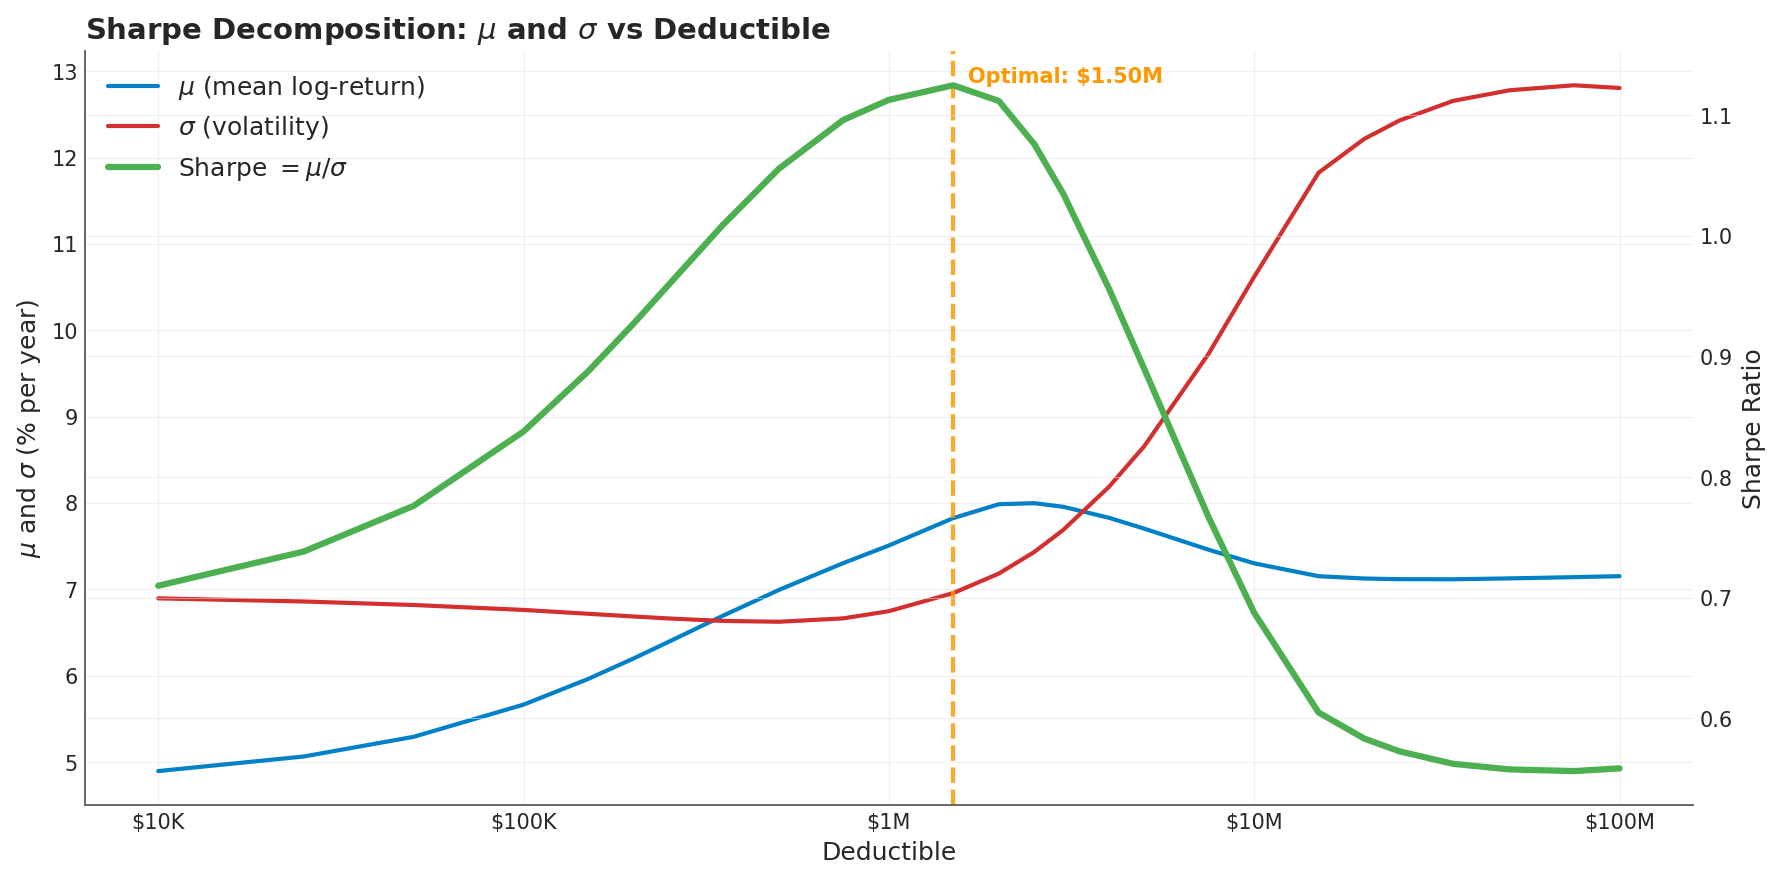

In [21]:
# --- Plot 1: Sharpe Decomposition (μ, σ, and Sharpe) ---
import matplotlib.transforms as mtransforms

fig, ax1 = plt.subplots(figsize=(12, 6), dpi=150)

# Left axis: μ and σ (the Sharpe numerator and denominator)
ln_mu, = ax1.semilogx(ded_M * 1e6, mean_log_rets * 100, color=COLOR_SEQUENCE[0],
                       lw=2, label=r'$\mu$ (mean log-return)')
ln_sig, = ax1.semilogx(ded_M * 1e6, std_log_rets * 100, color=COLOR_SEQUENCE[1],
                        lw=2, label=r'$\sigma$ (volatility)')
ax1.set_xlabel('Deductible')
ax1.set_ylabel(r'$\mu$ and $\sigma$ (% per year)')

# Right axis: Sharpe = μ / σ
ax2 = ax1.twinx()
ln_sh, = ax2.semilogx(ded_M * 1e6, sharpe_ratios, color=COLOR_SEQUENCE[2],
                       lw=3, label=r'Sharpe $= \mu / \sigma$')
ax2.set_ylabel('Sharpe Ratio')

# Optimal deductible vertical line
ax1.axvline(opt_M * 1e6, color=COLOR_SEQUENCE[3], ls='--', lw=2, alpha=0.85)

# Annotation
trans = mtransforms.blended_transform_factory(ax1.transData, ax1.transAxes)
ax1.text(opt_M * 1e6 * 1.1, 0.98,
         f'Optimal: ${opt_ded/1e6:.2f}M',
         fontsize=10, fontweight='bold', color=COLOR_SEQUENCE[3],
         ha='left', va='top', transform=trans)

# Combined legend
lines = [ln_mu, ln_sig, ln_sh]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='best', fontsize=12, framealpha=0.9)

ax1.xaxis.set_major_formatter(mticker.FuncFormatter(dollar_fmt))

ax1.set_title(r'Sharpe Decomposition: $\mu$ and $\sigma$ vs Deductible',
              fontweight='bold', loc='left', fontsize=14)
fig.tight_layout()
plt.savefig('cache/plot_12_sharpe_decomposition.png', dpi=150,
            bbox_inches='tight')
plt.show()

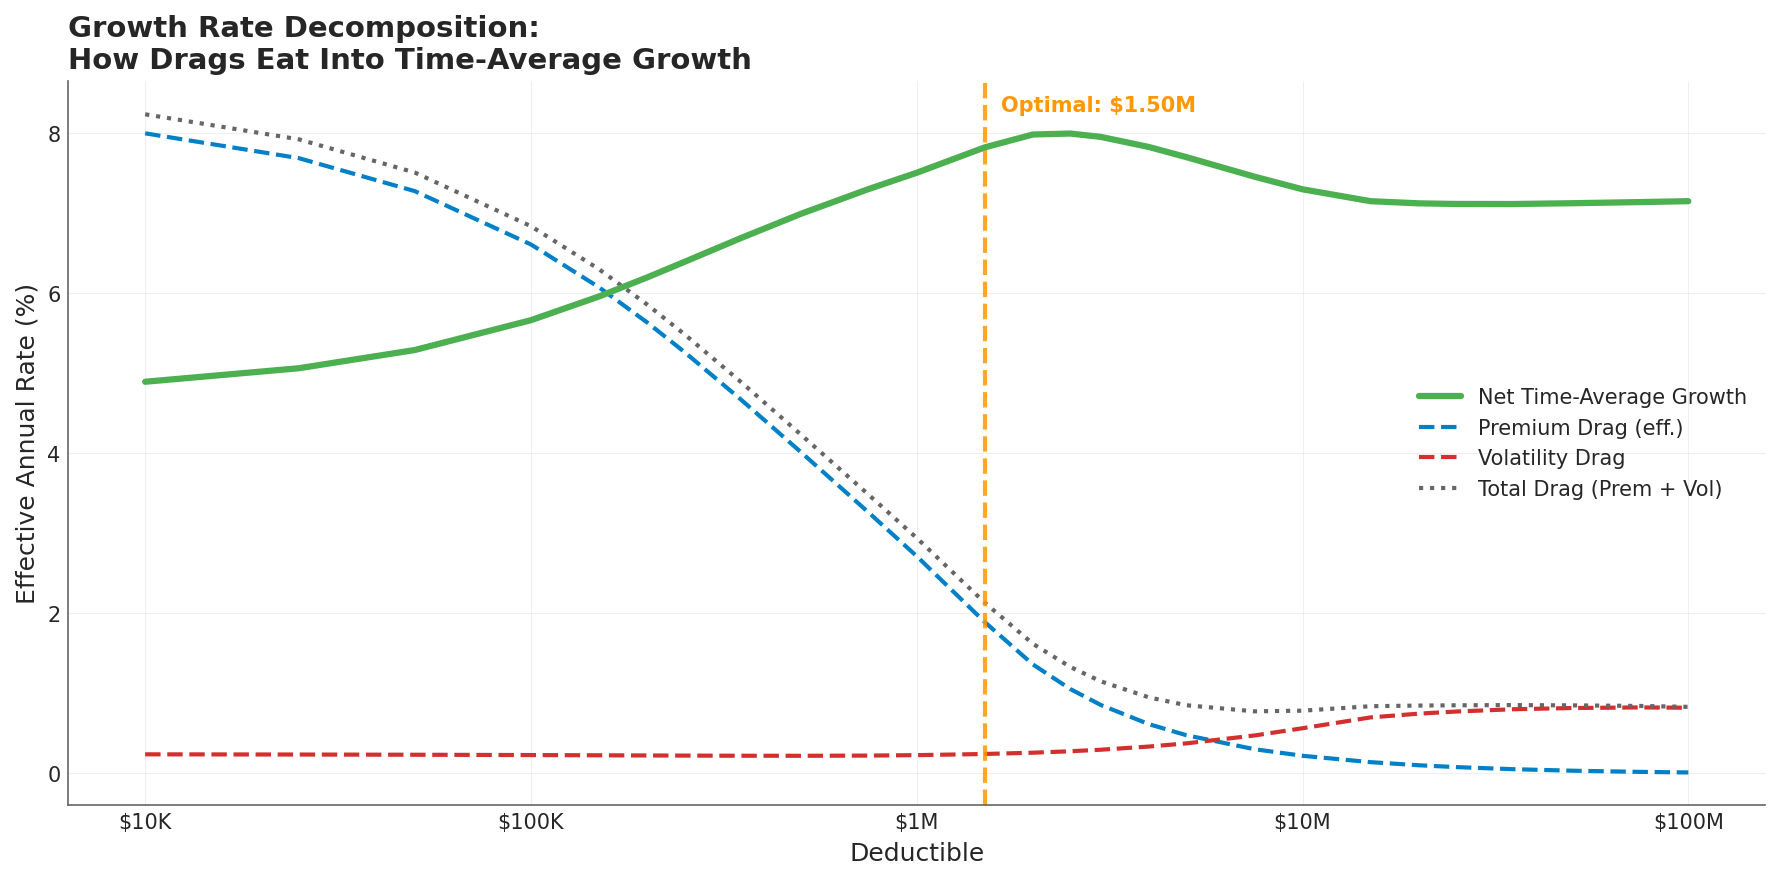

In [22]:
# --- Plot 2: Growth Rate Decomposition ---
fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

ax.semilogx(ded_M * 1e6, ta_growth_rates * 100, color=COLOR_SEQUENCE[2], lw=3,
            ms=5, label='Net Time-Average Growth', zorder=5)
ax.semilogx(ded_M * 1e6, premium_drags * 100, color=COLOR_SEQUENCE[0], lw=2,
            ms=4, ls='--', label='Premium Drag (eff.)')
ax.semilogx(ded_M * 1e6, vol_drags * 100, color=COLOR_SEQUENCE[1], lw=2,
            ms=4, ls='--', label='Volatility Drag')

# Total drag
total_drag = premium_drags + vol_drags
ax.semilogx(ded_M * 1e6, total_drag * 100,
            color=WSJ_COLORS.get('gray', 'gray'),
            lw=2, ls=':', label='Total Drag (Prem + Vol)')
# Optimal
ax.axvline(opt_M * 1e6, color=COLOR_SEQUENCE[3], ls='--', lw=2, alpha=0.85)

# Annotation
trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
ax.text(opt_M * 1e6 * 1.1, 0.98,
         f'Optimal: ${opt_ded/1e6:.2f}M',
         fontsize=10, fontweight='bold', color=COLOR_SEQUENCE[3],
         ha='left', va='top', transform=trans)


ax.set_xlabel('Deductible')
ax.set_ylabel('Effective Annual Rate (%)')
ax.set_title('Growth Rate Decomposition:\n'
             'How Drags Eat Into Time-Average Growth',
             fontweight='bold', loc='left', fontsize=14)
ax.legend(fontsize=10, loc='best')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(dollar_fmt))
fig.tight_layout()
plt.savefig('cache/plot_12_growth_decomposition.png', dpi=150,
            bbox_inches='tight')
plt.show()

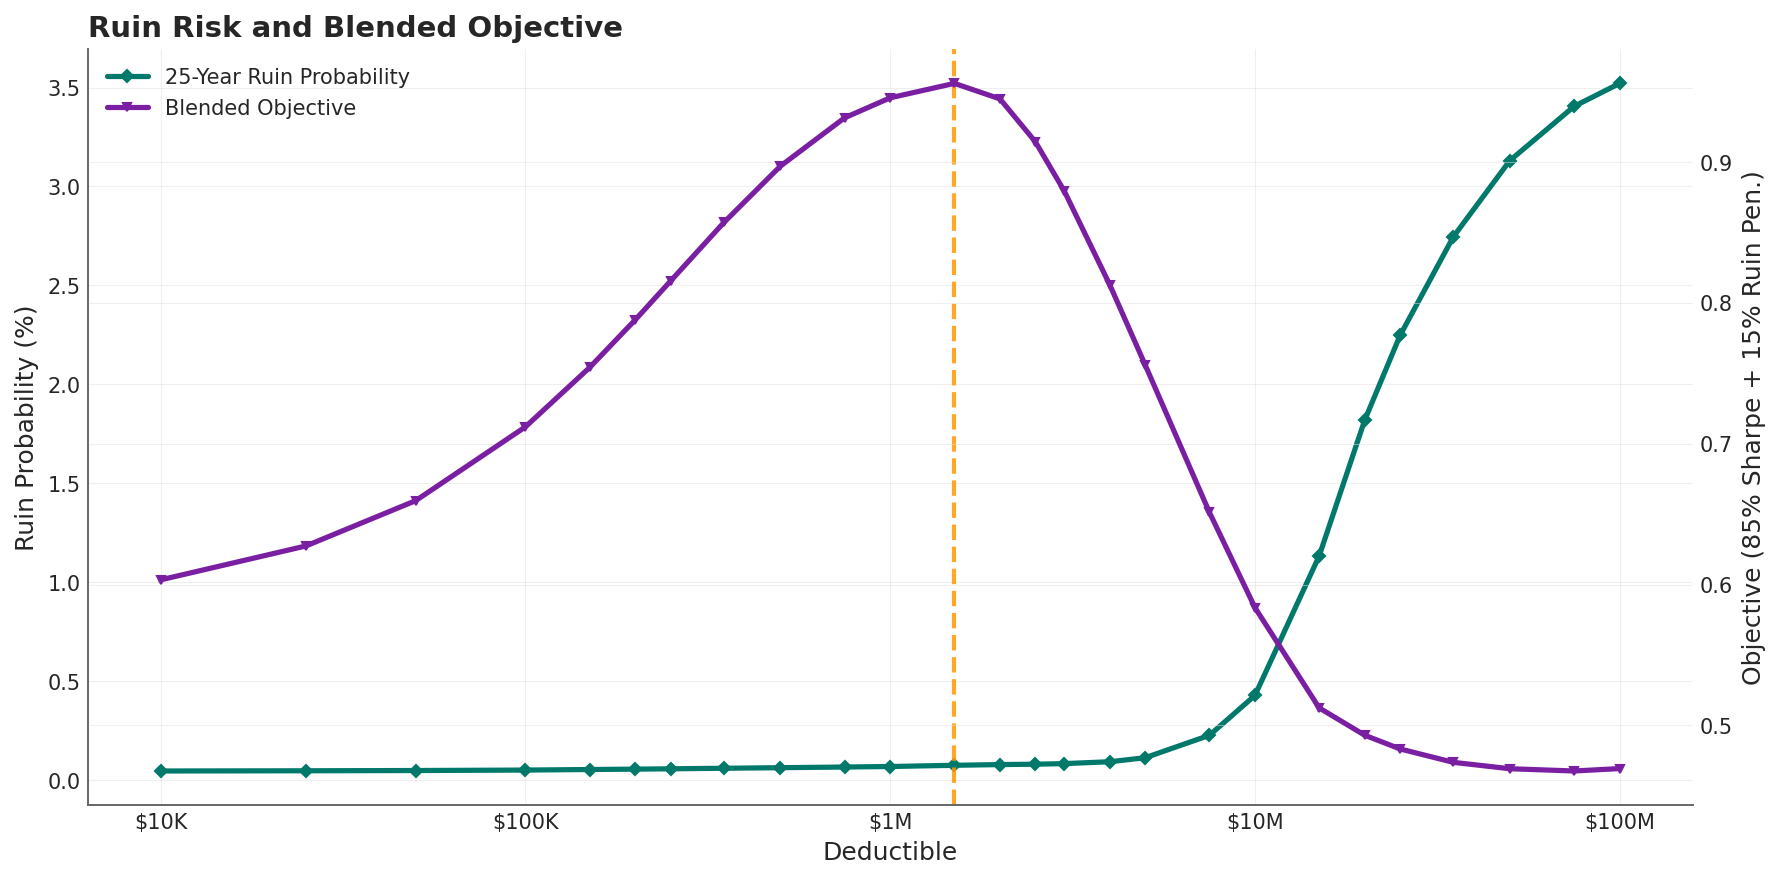

In [23]:
# --- Plot 3: Ruin Probability and Blended Objective ---
fig, ax1 = plt.subplots(figsize=(12, 6), dpi=150)

c_ruin = COLOR_SEQUENCE[5] if len(COLOR_SEQUENCE) > 3 else '#8B4513'
c_obj  = COLOR_SEQUENCE[4] if len(COLOR_SEQUENCE) > 4 else '#4B0082'

# Left axis: ruin probability
ln_r, = ax1.semilogx(ded_M * 1e6, ruin_probs * 100, color=c_ruin, lw=2.5,
                      marker='D', ms=4, label='25-Year Ruin Probability')
ax1.set_xlabel('Deductible')
ax1.set_ylabel('Ruin Probability (%)')

# Right axis: blended objective
ax2 = ax1.twinx()
ln_o, = ax2.semilogx(ded_M * 1e6, blended_objectives, color=c_obj, lw=2.5,
                      marker='v', ms=4, label='Blended Objective')
ax2.set_ylabel(f'Objective ({SHARPE_WEIGHT:.0%} Sharpe + '
               f'{RUIN_WEIGHT:.0%} Ruin Pen.)')

# Optimal
ax1.axvline(opt_M * 1e6, color=COLOR_SEQUENCE[3], ls='--', lw=2, alpha=0.85)

lines = [ln_r, ln_o]
ax1.legend(lines, [l.get_label() for l in lines], loc='best', fontsize=10)

ax1.set_title('Ruin Risk and Blended Objective',
              fontweight='bold', loc='left', fontsize=14)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(dollar_fmt))
fig.tight_layout()
plt.savefig('cache/plot_12_ruin_objective.png', dpi=150,
            bbox_inches='tight')
plt.show()

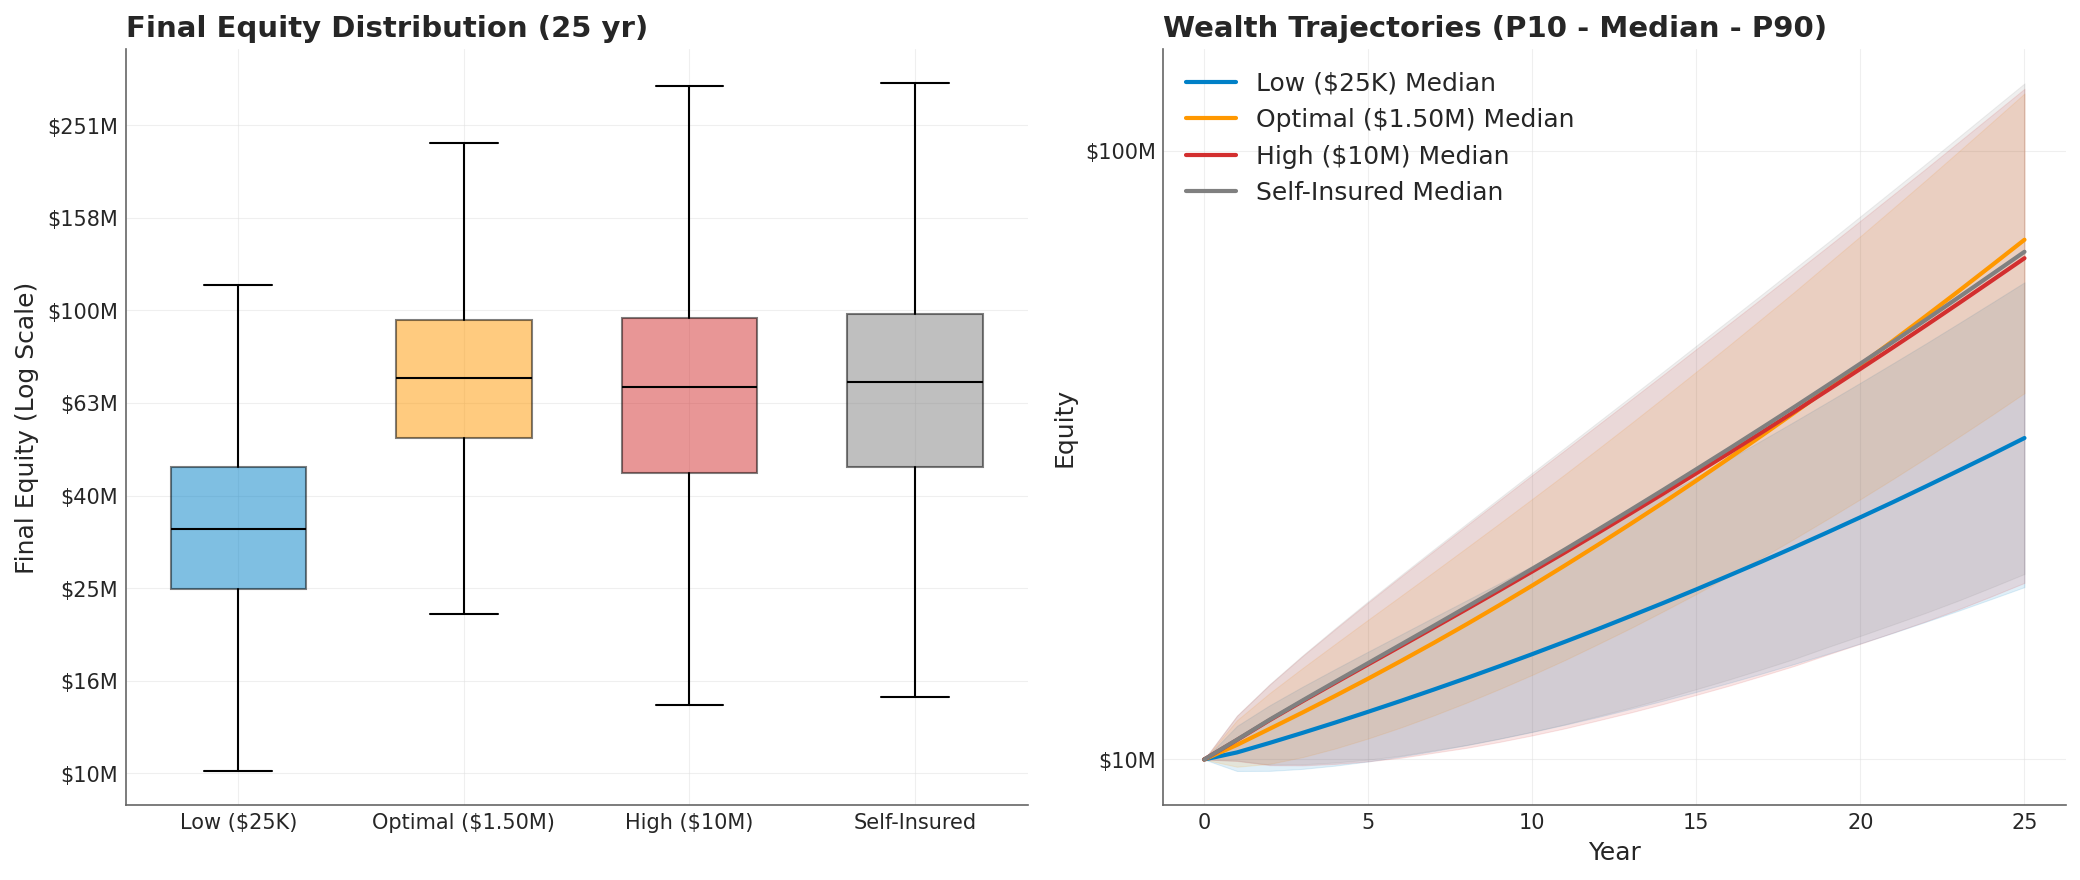

In [24]:
# --- Plot 4: Wealth Distribution Comparison ---
def exp_fmt(x, pos):
    return dollar_fmt(10 ** x, pos)

compare_labels = [
    f'Low (${DEDUCTIBLE_GRID[1]/1e3:.0f}K)',
    f'Optimal (${opt_ded/1e6:.2f}M)',
    f'High (${DEDUCTIBLE_GRID[-8]/1e6:.0f}M)',
    'Self-Insured',
]
compare_paths = [
    all_paths[0],          # lowest deductible
    all_paths[opt_idx],    # optimal
    all_paths[-1],         # highest deductible
    si_paths,              # no insurance
]
plot_colors = [COLOR_SEQUENCE[0], COLOR_SEQUENCE[3], COLOR_SEQUENCE[1], 'gray']

fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150)

# --- Left panel: box plot of log10(final equity) ---
box_data = [np.log10(np.maximum(p[:, -1][p[:, -1] > 0], 1))
            for p in compare_paths]
bp = axes[0].boxplot(box_data, labels=compare_labels, patch_artist=True,
                     showfliers=False, widths=0.6,
                     medianprops=dict(color='black', linewidth=1))
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(exp_fmt))
axes[0].set_ylabel(r'Final Equity (Log Scale)')
axes[0].set_title('Final Equity Distribution (25 yr)',
                  fontweight='bold', loc='left')
axes[0].tick_params(axis='x', rotation=0)

# --- Right panel: median wealth trajectory with P10-P90 bands ---
years = np.arange(N_YEARS + 1)
for paths_i, label, color in zip(compare_paths, compare_labels,
                                 plot_colors):
    p50 = np.median(paths_i, axis=0)
    p10 = np.percentile(paths_i, 10, axis=0)
    p90 = np.percentile(paths_i, 90, axis=0)
    axes[1].semilogy(years, p50, color=color, lw=2,
                     label=f'{label} Median')
    axes[1].fill_between(years, np.maximum(p10, 1), p90,
                         color=color, alpha=0.12)

axes[1].set_xlabel('Year')
axes[1].set_ylabel('Equity')
axes[1].set_title('Wealth Trajectories (P10 - Median - P90)',
                  fontweight='bold', loc='left')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(dollar_fmt))
axes[1].legend(fontsize=12, loc='upper left')

fig.tight_layout()
plt.savefig('cache/plot_12_wealth_comparison.png', dpi=150,
            bbox_inches='tight')
plt.show()

### Takeaways

1. **The deductible trade-off is real and quantifiable.** Lowering the deductible reduces $\sigma$ (smoother equity path) but suppresses $\mu$ (premium eats income). Raising the deductible recovers $\mu$ but inflates $\sigma$. The optimal sits where $\mu/\sigma$ is maximised, the point of best risk-adjusted compounding.

2. **Volatility is the hidden killer and $\sigma^2/2$ understates it.** Under multiplicative dynamics, $\sigma$ penalises growth through $\sigma^2/2$ (the Kelly drag) AND inflates the denominator of the Sharpe ratio. A doubling of $\sigma$ from 7% to 13% shows up as a modest 0.6 percentage-point increase in $\sigma^2/2$, but it halves the Sharpe ratio. Catastrophic losses don't just reduce equity by their dollar amount, they permanently destroy the compounding base.

3. **Insurance is a growth strategy at the optimum.** The optimal deductible achieves both a higher Sharpe ratio and a lower ruin probability than self-insurance. The company pays a premium that exceeds expected insured losses (by the insurer's margin), yet its long-run equity growth rate is *higher* than if it retained all risk. This is the ergodic insight: actuarially "unfair" insurance can be economically rational when growth compounds multiplicatively.

4. **Ruin risk creates a cliff.** At very high deductibles, ruin probability rises non-linearly as the company retains catastrophic exposure without adequate capital buffers. The ruin penalty in the blended objective catches this cliff before it dominates, in some cases pulling the optimal deductible below the pure Sharpe-maximising point.